In [1]:
import matplotlib.pyplot as plt 
import pickle 
import SimpleITK as sitk
import numpy as np
from skimage import measure, morphology
import scipy 
from tps import ThinPlateSpline
from torch_tps import ThinPlateSpline as ThinPlateSplineGPU
import random
import torch
import numpy as np
import itk
from skimage import measure, morphology
import os

In [5]:
np.random.randint(0,2)

1

In [60]:
def ensure_bounds(points,shape):
    points[:,0] = np.clip(points[:,0], 0, shape[0]-1)
    points[:,1] = np.clip(points[:,1], 0, shape[1]-1)
    points[:,2] = np.clip(points[:,2], 0, shape[2]-1)
    return points 

def sample_along_line(p, center, dist):
    # Given a point p, a center point, and a distance dist, return a new point that is dist away from p along the line connecting p and center
    direction = center - p
    direction_norm = np.linalg.norm(direction, axis = 1)
    direction_unit = direction / direction_norm.reshape(-1,1)
    new_point = p + direction_unit * dist
    return new_point

def get_grid_points():
    x = np.linspace(4, 60, 5).astype(int)
    y = np.linspace(4, 60, 5).astype(int)
    z = np.linspace(4, 60, 5).astype(int)
    x, y, z = np.meshgrid(x, y, z)
    grid_points = np.vstack([x.ravel(), y.ravel(), z.ravel()]).T
    return list(grid_points)

def filter_border_points(points, shape, margin = 1):
    mask = (points[:,0] > margin) & (points[:,0] < shape[0]-margin) & \
           (points[:,1] > margin) & (points[:,1] < shape[1]-margin) & \
           (points[:,2] > margin) & (points[:,2] < shape[2]-margin)
    return mask

def touches_border(label):
    # check if a binary label touches the border of the volume
    if np.any(label[0,:,:]) or np.any(label[-1,:,:]) or \
       np.any(label[:,0,:]) or np.any(label[:,-1,:]) or \
       np.any(label[:,:,0]) or np.any(label[:,:,-1]):
        return True
    else:
        return False


In [253]:
class SplineTransform():
    """Use a spline to shrink the aneurysm surface towards the center, while keeping the rest of the volume mostly unchanged"""

    def __init__(self, p=0.5, order=3, shrink_factor = 8, max_points_surf=200, max_points_dilated=100, use_grid_controls = True, device = "cpu"):
        """
        Args:
            p (float): probability of applying the transform.
            order (int): The order of the spline interpolation, default is 3.
            shrink_factor (float): Factor to determine how much to shrink surface points towards the center, as a divisor of minor axis length
            max_points_surf (int): Maximum number of surface points to sample.
            max_points_dilated (int): Maximum number of dilated surface points to sample.
            use_grid_controls (bool): Whether to use grid points outside the dilated label as control points.
            device (str): "cpu" or "cuda"
        """
        self.p = p
        self.order = order
        self.shrink_factor = shrink_factor
        self.max_points_surf = max_points_surf
        self.max_points_dilated = max_points_dilated
        self.use_grid_controls = use_grid_controls
        self.device = device
        if device == "cpu":
            self.fun_spline = self.transform_with_splines_cpu
        elif device == "cuda":
            self.fun_spline = self.transform_with_splines_gpu

    def __call__(self, sample):
            if len(sample["ctr"]) != 1 or random.random() > self.p or touches_border(sample["label"][0]):
                return sample
            image = sample["image"][0]
            label = sample["label"][0]
            arrays = [image, label]
            if "mask" in sample:
                mask = sample["mask"][0]
                arrays.append(mask)
            
            if "cvs_mask" in sample:
                cvs_mask = sample["cvs_mask"][0]
                arrays.append(cvs_mask)
            
            try:
                points, points_target = self.get_transform_points(label)
            except Exception as e:
                print(e)
                print(sample)
                return sample
                
            # rearrange points and points_target as z,x,y
            arrays_t = self.fun_spline(arrays, points, points_target)
            sample["image"] = arrays_t[0]
            sample["label"] = arrays_t[1]
            #sample["points"] = points
            #sample["points_target"] = points_target
            if "mask" in sample:
                sample["mask"] = arrays_t[2]
            if "cvs_mask" in sample:
                sample["cvs_mask"] = arrays_t[3]
            
            return sample
    
    def transform_with_splines_cpu(self, arrays, source, target):
        tps = ThinPlateSpline(0.5, order=self.order, enforce_tps_kernel=True)
        tps.fit(target, source)
        height, width, depth = arrays[0].shape
        output_indices = np.indices((height, width, depth), dtype=np.float64).transpose(
            1, 2, 3, 0
        ) 
        input_indices = tps.transform(output_indices.reshape(-1, 3)).reshape(
            height, width, depth, 3
        )
        output_arrays = []
        for array in arrays:
            deformed_array = scipy.ndimage.map_coordinates(
                np.array(array), input_indices.transpose(3, 0, 1, 2), order=self.order, mode="grid-constant"
            )[np.newaxis, ...]
            output_arrays.append(deformed_array)
        return output_arrays

    def transform_with_splines_gpu(self, arrays, source, target):
        # convert arrays to tensors 
        
        arrays = [torch.from_numpy(array).float().to("cuda:0") for array in arrays]
        source = torch.from_numpy(source).float().to("cuda:0")
        target = torch.from_numpy(target).float().to("cuda:0")
        
        tps = ThinPlateSplineGPU(0.1, order=self.order, enforce_tps_kernel=True, device="cuda:0")
        tps.fit(target, source)
        height, width, depth = arrays[0].size()

        i = torch.arange(height, dtype=torch.float32)
        j = torch.arange(width, dtype=torch.float32)
        k = torch.arange(depth, dtype=torch.float32)
        ii, jj, kk = torch.meshgrid(i, j, k, indexing='ij')
        output_indices = torch.cat((ii[..., None], jj[..., None], kk[..., None]), dim=-1).to("cuda:0")  # Shape: (H, W, D, 3)
        input_indices = tps.transform(output_indices.reshape(-1, 3)).reshape(
            height, width, depth, 3
        )
        grid = input_indices.clone()
        grid[..., 0] = 2.0 * grid[..., 0] / (
            height - 1
        ) - 1.0
        grid[..., 1] = 2.0 * grid[..., 1] / (
            width - 1
        ) - 1.0
        grid[..., 2] = 2.0 * grid[..., 2] / (
            depth - 1
        ) - 1.0
        
        newgrid = grid.clone()
        newgrid[..., 0] = grid[..., 2]
        newgrid[..., 1] = grid[..., 1]
        newgrid[..., 2] = grid[..., 0]

        output_arrays = []
        for array in arrays:
            array = array.unsqueeze(0).unsqueeze(0)
            deformed_array = torch.nn.functional.grid_sample(array, newgrid.unsqueeze(0), mode='bilinear', padding_mode='border', align_corners=False)
            deformed_array = deformed_array.squeeze(0).cpu().numpy()
            output_arrays.append(deformed_array)
        return output_arrays
    

    def get_transform_points(self, label):
        surface_points = measure.marching_cubes(label, spacing=[1, 1, 1])[0]
        num_points = self.max_points_surf if len(surface_points) > self.max_points_surf else len(surface_points)
        indices = np.random.choice(len(surface_points), num_points, replace=False)
        surface_points = surface_points[indices]
        feats = measure.regionprops(label.astype(int))
        print(feats[0].bbox)
        center = np.array(feats[0].centroid)
        # shrink by a random fraction of minor axis length, centered around a shrink factor
        shrink_factor = np.random.randint(self.shrink_factor-1, self.shrink_factor+1)
        minor_axis_factor = np.random.normal(shrink_factor, 0.25, len(surface_points)).reshape(-1, 1)
        amp = feats[0].axis_minor_length / minor_axis_factor
        surface_points_change = sample_along_line(surface_points, center, amp)
        # apply mask to keep border points unchanged
        mask_surface_points = filter_border_points(surface_points, label.shape, margin=3)
        surface_points_change[~mask_surface_points] = surface_points[~mask_surface_points]

        # sample control points from dilated surface
        selem = np.ones((7, 7, 7), dtype=bool)
        label_dilated = morphology.binary_dilation(label, footprint=selem)
        surface_points_dilated = measure.marching_cubes(
            label_dilated, spacing=[1, 1, 1]
        )[0].astype(int)
        num_points_dilated = (
            self.max_points_dilated if len(surface_points_dilated) > self.max_points_dilated else len(surface_points_dilated)
        )
        indices = np.random.choice(
            len(surface_points_dilated), num_points_dilated, replace=False
        )
        surface_points_dilated = ensure_bounds(surface_points_dilated[indices], label.shape)

        # sample a grid outside the dilated label as additional control points
        # for the rest of the volume

        points = np.concatenate(
            [surface_points, surface_points_dilated, center.reshape(-1, 3)],
            axis=0,
        )
        points_target = np.concatenate(
            [
                surface_points_change,
                surface_points_dilated,
                center.reshape(-1, 3),
            ],
            axis=0,
        )
        if self.use_grid_controls:
            grid_64 = get_grid_points()
            grid_64 = [point for point in grid_64 if label_dilated[tuple(point)] != 1]
            points = np.concatenate([points, grid_64], axis=0)
            points_target = np.concatenate([points_target, grid_64], axis=0)

        return points, points_target

In [254]:
name = "variant_1"
p = 1
order = 3
shrink_factor = 8
max_points_surf = 200
max_points_dilated = 100
use_grid_controls = True
device = "cpu"

# name = "variant_2"
# p = 1
# order = 2
# shrink_factor = 8
# max_points_surf = 200
# max_points_dilated = 100
# use_grid_controls = True 

# name = "variant_3"
# p = 1
# order = 3
# shrink_factor = 6
# max_points_surf = 200
# max_points_dilated = 100
# use_grid_controls = True 

# name = "variant_4"
# p = 1
# order = 3
# shrink_factor = 8
# max_points_surf = 100
# max_points_dilated = 50
# use_grid_controls = False

# name = "variant_5"
# p = 1
# order = 3
# shrink_factor = 6
# max_points_surf = 100
# max_points_dilated = 50
# use_grid_controls = False

name = "variant_6"
p = 1
order = 3
shrink_factor = 8
max_points_surf = 200
max_points_dilated = 100
use_grid_controls = True
device = "cuda"


In [260]:
cont = True
folder = "scans_test/"
all_files = os.listdir(folder)

saved = []
saved_full = []

indices = [0,1,2,3,4,5,6,7]

for i in indices:
    with open(f"{folder+all_files[i]}", "rb") as f:
        scan_id = all_files[i].split(".nii.gz")[0].split("sample_")[-1]
        scan_id_full = all_files[i].split(".pkl")[0].split("sample_")[-1]
        sample = pickle.load(f)
    if len(sample["ctr"]) != 1 or np.min(sample["rad"]) < 4 or touches_border(sample["label"][0]):
        continue
    image = sample["image"][0]
    label = label_orig = sample["label"][0]
    ctr = sample["ctr"].astype(int)[0]
    rad = sample["rad"].astype(int)[0]
    print(ctr,rad)
    # get itk volumes from original objects 

    image_itk = sitk.GetImageFromArray(image)
    label_itk = sitk.GetImageFromArray(label)

    # save under "review_contents/orig/orig_{i}.nii.gz"
    #mkdir orig
    os.makedirs("review_contents/orig", exist_ok=True)
    os.makedirs(f"review_contents/{name}", exist_ok=True)

    sitk.WriteImage(image_itk, f"review_contents/orig/scan_orig_{i}.nii.gz")
    sitk.WriteImage(label_itk, f"review_contents/orig/label_orig_{i}.nii.gz")

    spline_transform = SplineTransform(p, order, shrink_factor, max_points_surf, max_points_dilated, use_grid_controls, device)
    sample_t = spline_transform(sample)
    image_t = sample_t["image"][0]
    label_t = sample_t["label"][0]
    ctr_t = sample_t["ctr"].astype(int)[0]
    rad_t = sample_t["rad"].astype(int)[0]

    # save under "review_contents/{name}/" 
    
    image_t_itk = sitk.GetImageFromArray(image_t)
    label_t_itk = sitk.GetImageFromArray(label_t)
    print(f"Writing {scan_id_full} {i}: ctr {ctr_t}, rad {rad_t}")
    sitk.WriteImage(image_t_itk, f"review_contents/{name}/scan_trans_{i}.nii.gz")
    sitk.WriteImage(label_t_itk, f"review_contents/{name}/label_trans_{i}.nii.gz")
    saved.append(scan_id)
    saved_full.append(scan_id_full)

    
    if (len(saved_full) == 8):
        break
        
        



[22 44 24] [9 8 5]
(21, 41, 23, 26, 48, 27)
Writing Tr0186.nii.gz_0 0: ctr [22 44 24], rad [9 8 5]
[23 45 15] [6 6 9]
(22, 44, 12, 27, 49, 20)
Writing Tr0186.nii.gz_2 2: ctr [23 45 15], rad [6 6 9]
[30 38 45] [ 4 11  6]
(30, 35, 44, 32, 42, 48)
Writing Tr0186.nii.gz_3 3: ctr [30 38 45], rad [ 4 11  6]
[36 26 51] [7 8 9]
(33, 24, 48, 39, 32, 55)
Writing Tr0186.nii.gz_6 6: ctr [36 26 51], rad [7 8 9]
[29 37 13] [7 9 7]
(26, 33, 11, 32, 41, 17)
Writing Tr0186.nii.gz_7 7: ctr [29 37 13], rad [7 9 7]


In [261]:
lab = sample["label"]

rad = sample["rad"]

feats = measure.regionprops(lab[0].astype(int))[0]
# print bounding box props
print(feats.bbox)
print(feats.centroid)
bbox = feats.bbox
height = bbox[3] - bbox[0]
width = bbox[4] - bbox[1]
depth = bbox[5] - bbox[2]
print("height, width, depth:", height, width, depth)

feats = measure.regionprops(label_orig.astype(int))[0]

bbox = feats.bbox
height = bbox[3] - bbox[0]
width = bbox[4] - bbox[1]
depth = bbox[5] - bbox[2]

print(feats.centroid)
print("height, width, depth:", height, width, depth)


sample["rad"], sample["ctr"]


(29, 35, 14, 30, 36, 15)
(29.0, 35.0, 14.0)
height, width, depth: 1 1 1
(28.746031746031747, 36.07936507936508, 13.904761904761905)
height, width, depth: 6 8 6


(array([[7.674379  , 9.01120618, 7.22000485]]),
 array([[29.21704542, 37.17701292, 13.83056035]]))

[7 9 7] [[7.674379   9.01120618 7.22000485]]
[29 37 13] [29 37 13]


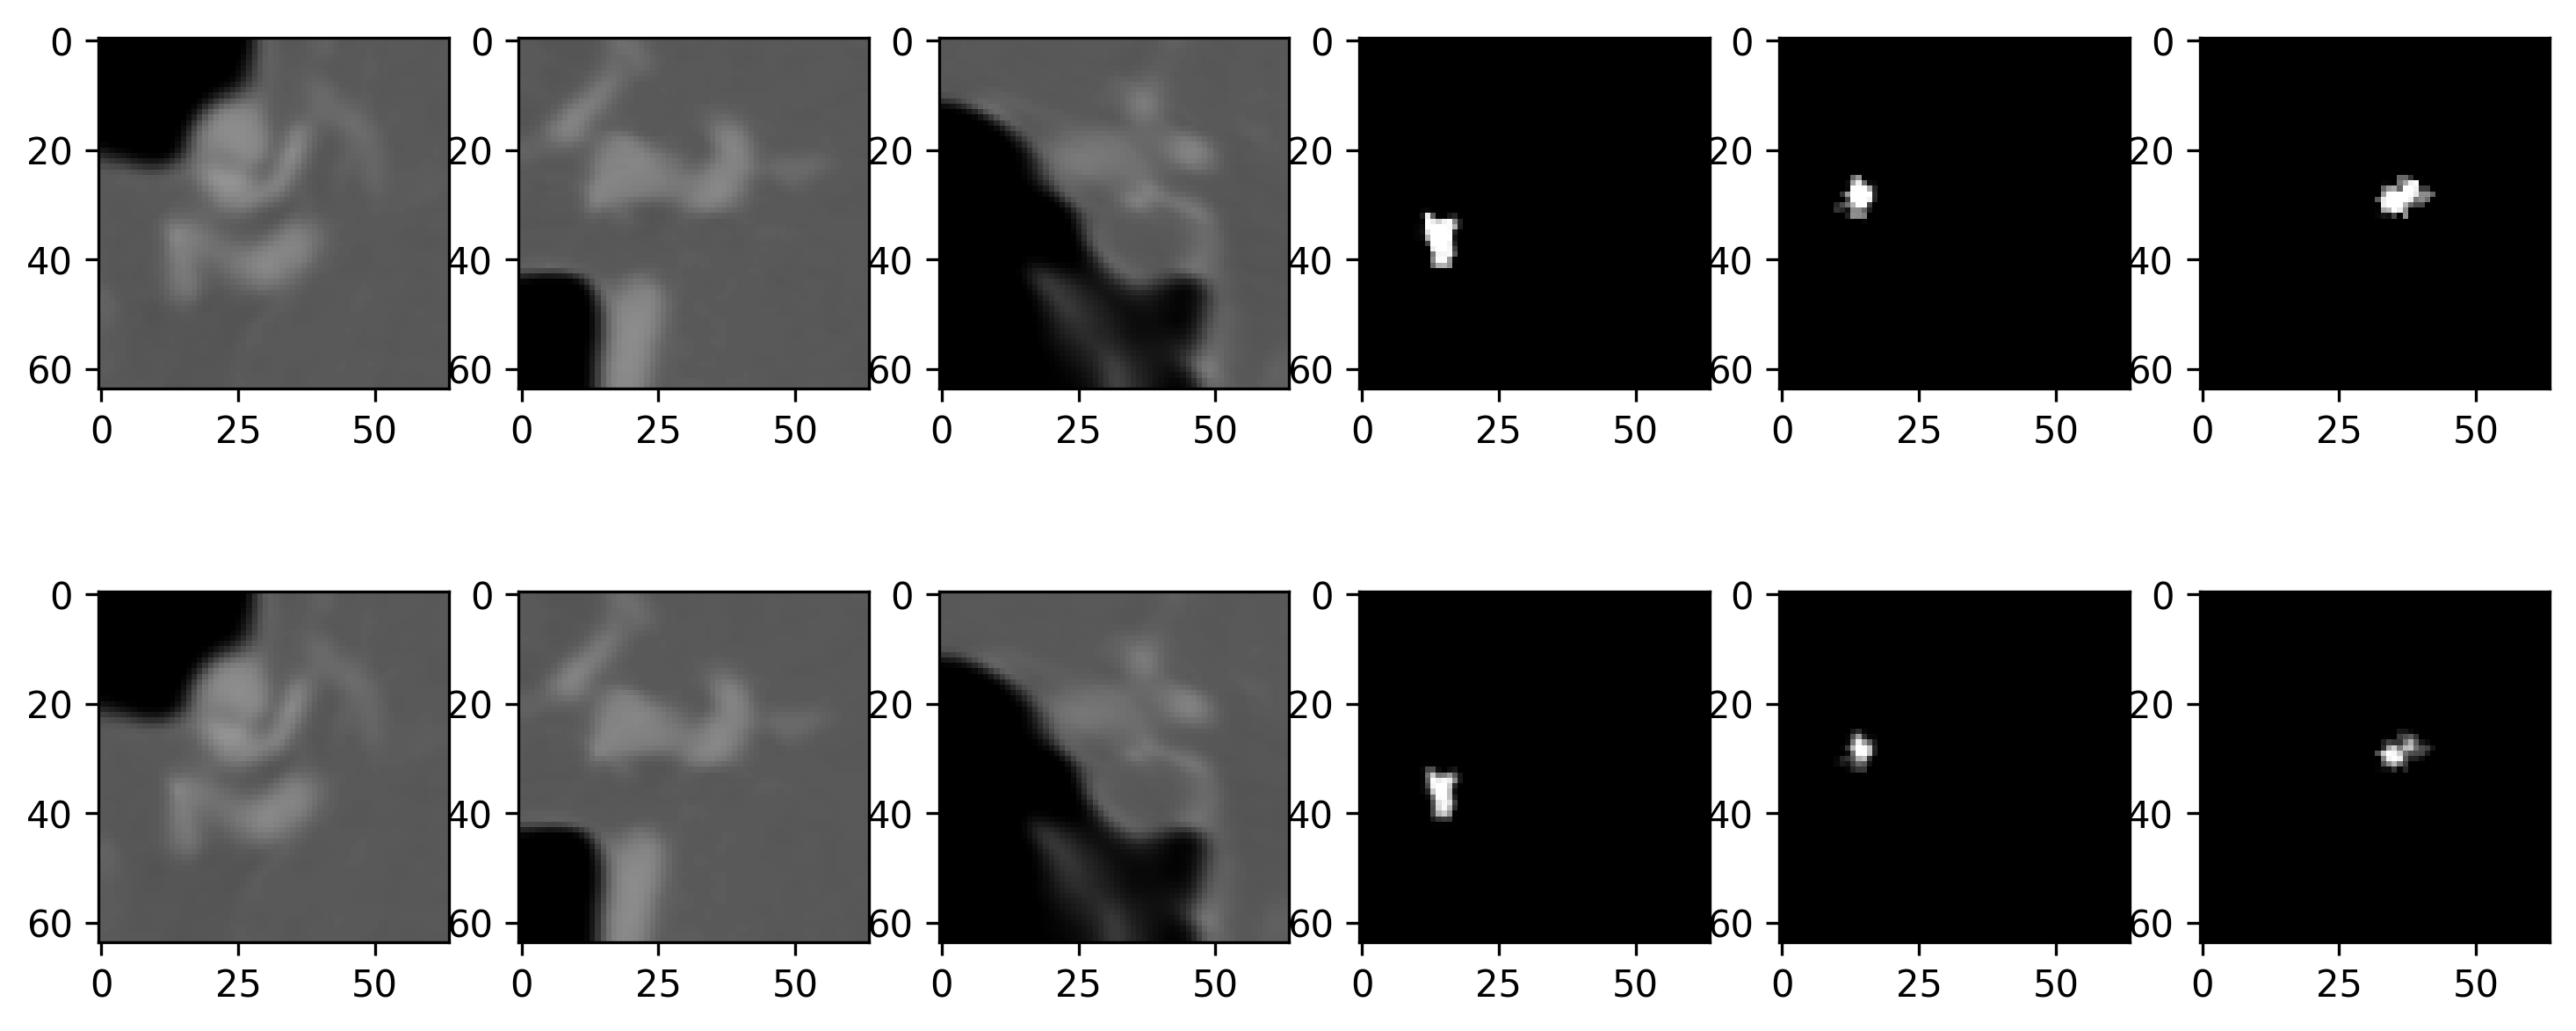

In [262]:
fig, axs = plt.subplots(2,6, dpi= 300, figsize=(12,5))

axs[0,0].imshow(image[ ctr[0],:,:], cmap="gray", vmin=-1000, vmax=2000)
axs[0,1].imshow(image[:,ctr[1],:], cmap="gray", vmin=-1000, vmax=2000)
axs[0,2].imshow(image[:,:,ctr[2]], cmap="gray", vmin=-1000, vmax=2000)

axs[0,3].imshow(label[ ctr[0],:,:], cmap="gray")
axs[0,4].imshow(label[:,ctr[1],:], cmap="gray")
axs[0,5].imshow(label[:,:,ctr[2]], cmap="gray")

axs[1,0].imshow(image_t[ ctr_t[0],:,:], cmap="gray", vmin=-1000, vmax=2000)
axs[1,1].imshow(image_t[:,ctr_t[1],:], cmap="gray", vmin=-1000, vmax=2000)
axs[1,2].imshow(image_t[:,:,ctr_t[2]], cmap="gray", vmin=-1000, vmax=2000)

axs[1,3].imshow(label_t[ ctr_t[0],:,:], cmap="gray")
axs[1,4].imshow(label_t[:,ctr_t[1],:], cmap="gray")
axs[1,5].imshow(label_t[:,:,ctr_t[2]], cmap="gray")

print(rad_t, rad)
print(ctr_t, ctr)

[7 9 7] [[7.674379   9.01120618 7.22000485]]
[29 37 13] [29 37 13]


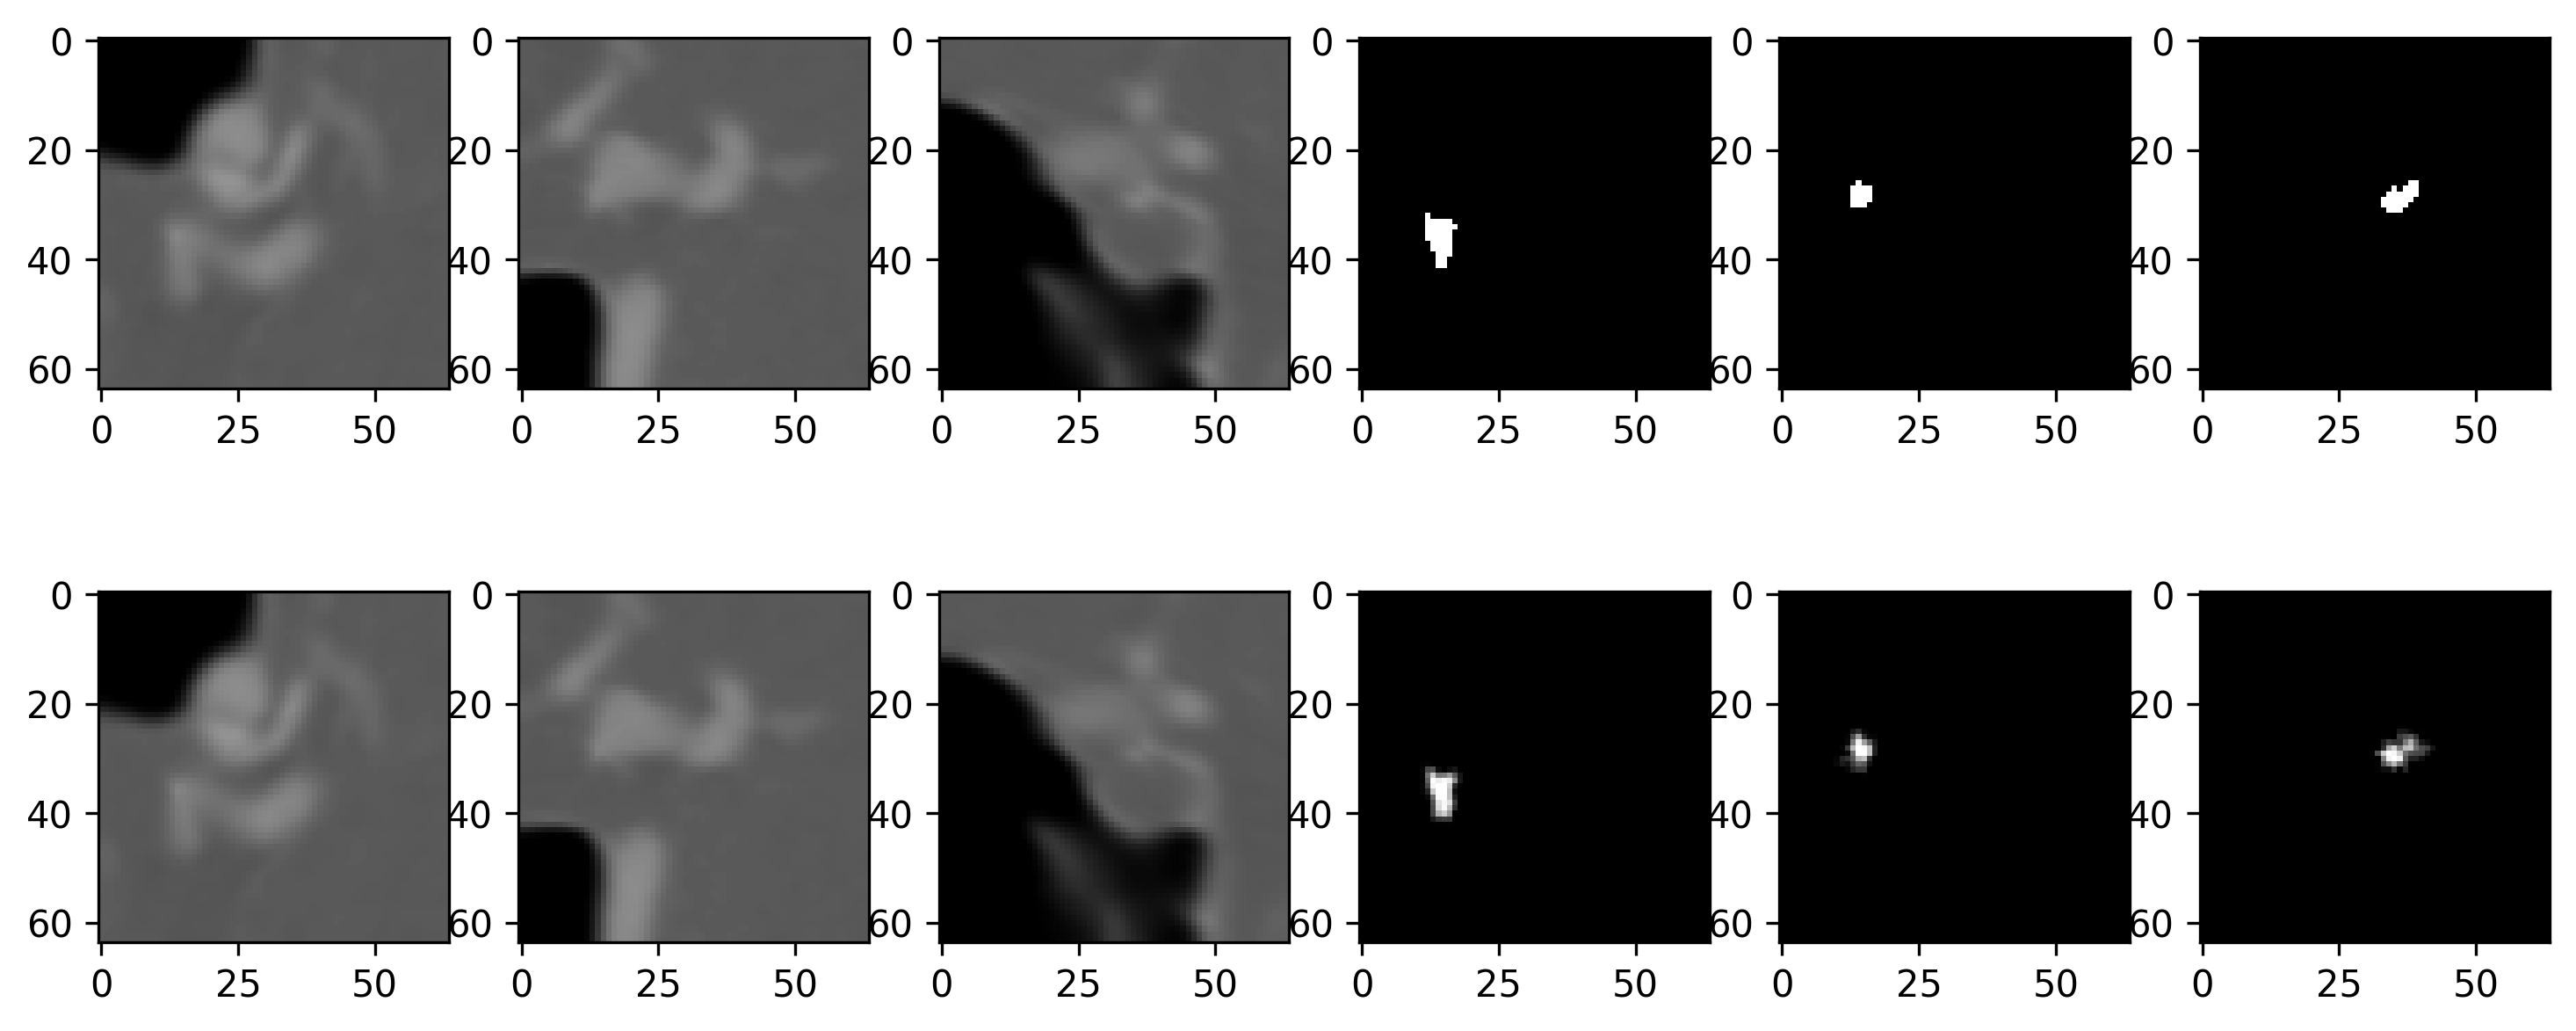

In [263]:
fig, axs = plt.subplots(2,6, dpi= 300, figsize=(12,5))
label = (label > 0.66).astype(int)
axs[0,0].imshow(image[ ctr[0],:,:], cmap="gray", vmin=-1000, vmax=2000)
axs[0,1].imshow(image[:,ctr[1],:], cmap="gray", vmin=-1000, vmax=2000)
axs[0,2].imshow(image[:,:,ctr[2]], cmap="gray", vmin=-1000, vmax=2000)

axs[0,3].imshow(label[ ctr[0],:,:], cmap="gray")
axs[0,4].imshow(label[:,ctr[1],:], cmap="gray")
axs[0,5].imshow(label[:,:,ctr[2]], cmap="gray")

axs[1,0].imshow(image_t[ ctr_t[0],:,:], cmap="gray", vmin=-1000, vmax=2000)
axs[1,1].imshow(image_t[:,ctr_t[1],:], cmap="gray", vmin=-1000, vmax=2000)
axs[1,2].imshow(image_t[:,:,ctr_t[2]], cmap="gray", vmin=-1000, vmax=2000)

axs[1,3].imshow(label_t[ ctr_t[0],:,:], cmap="gray")
axs[1,4].imshow(label_t[:,ctr_t[1],:], cmap="gray")
axs[1,5].imshow(label_t[:,:,ctr_t[2]], cmap="gray")

print(rad_t, rad)
print(ctr_t, ctr)

In [242]:
path_file = "scans_test/sample_Tr0751.nii.gz_6.pkl"

with open(path_file, "rb") as f:
    sample = pickle.load(f)

sample.keys()

dict_keys(['scan_id', 'image', 'ctr', 'rad', 'cls', 'label', 'mask', 'volume', 'label_orig', 'ctr_orig', 'rad_orig', 'annot'])

In [243]:
# get bbox for label and label_orig 

label = sample["label"][0]
label_orig = sample["label_orig"][0]

feats = measure.regionprops(label_orig.astype(int))[0]

bbox = feats.bbox
height = bbox[3] - bbox[0]
width = bbox[4] - bbox[1]
depth = bbox[5] - bbox[2]

rad_calc_orig = height, width, depth
centroid_orig =  feats.centroid


feats = measure.regionprops(label.astype(int))[0]

bbox = feats.bbox
# get size in x, y, z from bbox
height = bbox[3] - bbox[0]
width = bbox[4] - bbox[1]
depth = bbox[5] - bbox[2]


rad_calc = height, width, depth
centroid =  feats.centroid


print(f"rad: {sample['rad']}, rad_calc: {rad_calc}")
print(f"ctr: {sample['ctr']}, ctr_calc: {centroid}")
print(f"rad_orig: {sample['rad_orig']}, rad_calc_orig: {rad_calc_orig}")
print(f"ctr_orig: {sample['ctr_orig']}, ctr_calc_orig: {centroid_orig}")

rad: [[5.40131357 5.84106181 2.63997797]], rad_calc: (5, 7, 4)
ctr: [[37.35464169 47.58505241 21.29168984]], ctr_calc: (37.19565217391305, 47.65217391304348, 22.08695652173913)
rad_orig: [[6.41133958 3.65000397 6.85108782]], rad_calc_orig: (6, 4, 7)
ctr_orig: [[25.64535831 21.29168984 15.41494759]], ctr_calc_orig: (25.6, 22.066666666666666, 15.266666666666667)


In [244]:
label = sample["label"][0]
labelled_object = measure.label(label)
feats = measure.regionprops(labelled_object.astype(int))
height = np.array([p.bbox[3] - p.bbox[0] for p in feats])
width = np.array([p.bbox[4] - p.bbox[1] for p in feats])
depth = np.array([p.bbox[5] - p.bbox[2] for p in feats])

rad = np.stack([height, width, depth], axis=-1)
rad, sample["rad"]

(array([[5, 7, 4]]), array([[5.40131357, 5.84106181, 2.63997797]]))

In [ ]:
(array([[ 6, 12, 16]]), array([[ 4.2539377, 10.2539377, 16.2539377]]))

In [232]:
label = sample["label"][0]
labelled_object = measure.label(label)
feats = measure.regionprops(labelled_object.astype(int))
height = np.array([p.bbox[3] - p.bbox[0] for p in feats])
width = np.array([p.bbox[4] - p.bbox[1] for p in feats])
depth = np.array([p.bbox[5] - p.bbox[2] for p in feats])

rad = np.stack([height, width, depth], axis=-1)
rad, sample["rad"]

(array([[ 6, 12, 16]]), array([[ 4.2539377, 10.2539377, 16.2539377]]))

In [123]:
depth

array([57])

[ 8 13 13] [[ 4  3 11]
 [ 3  8 11]]
[19 22 16] [25 18 51]


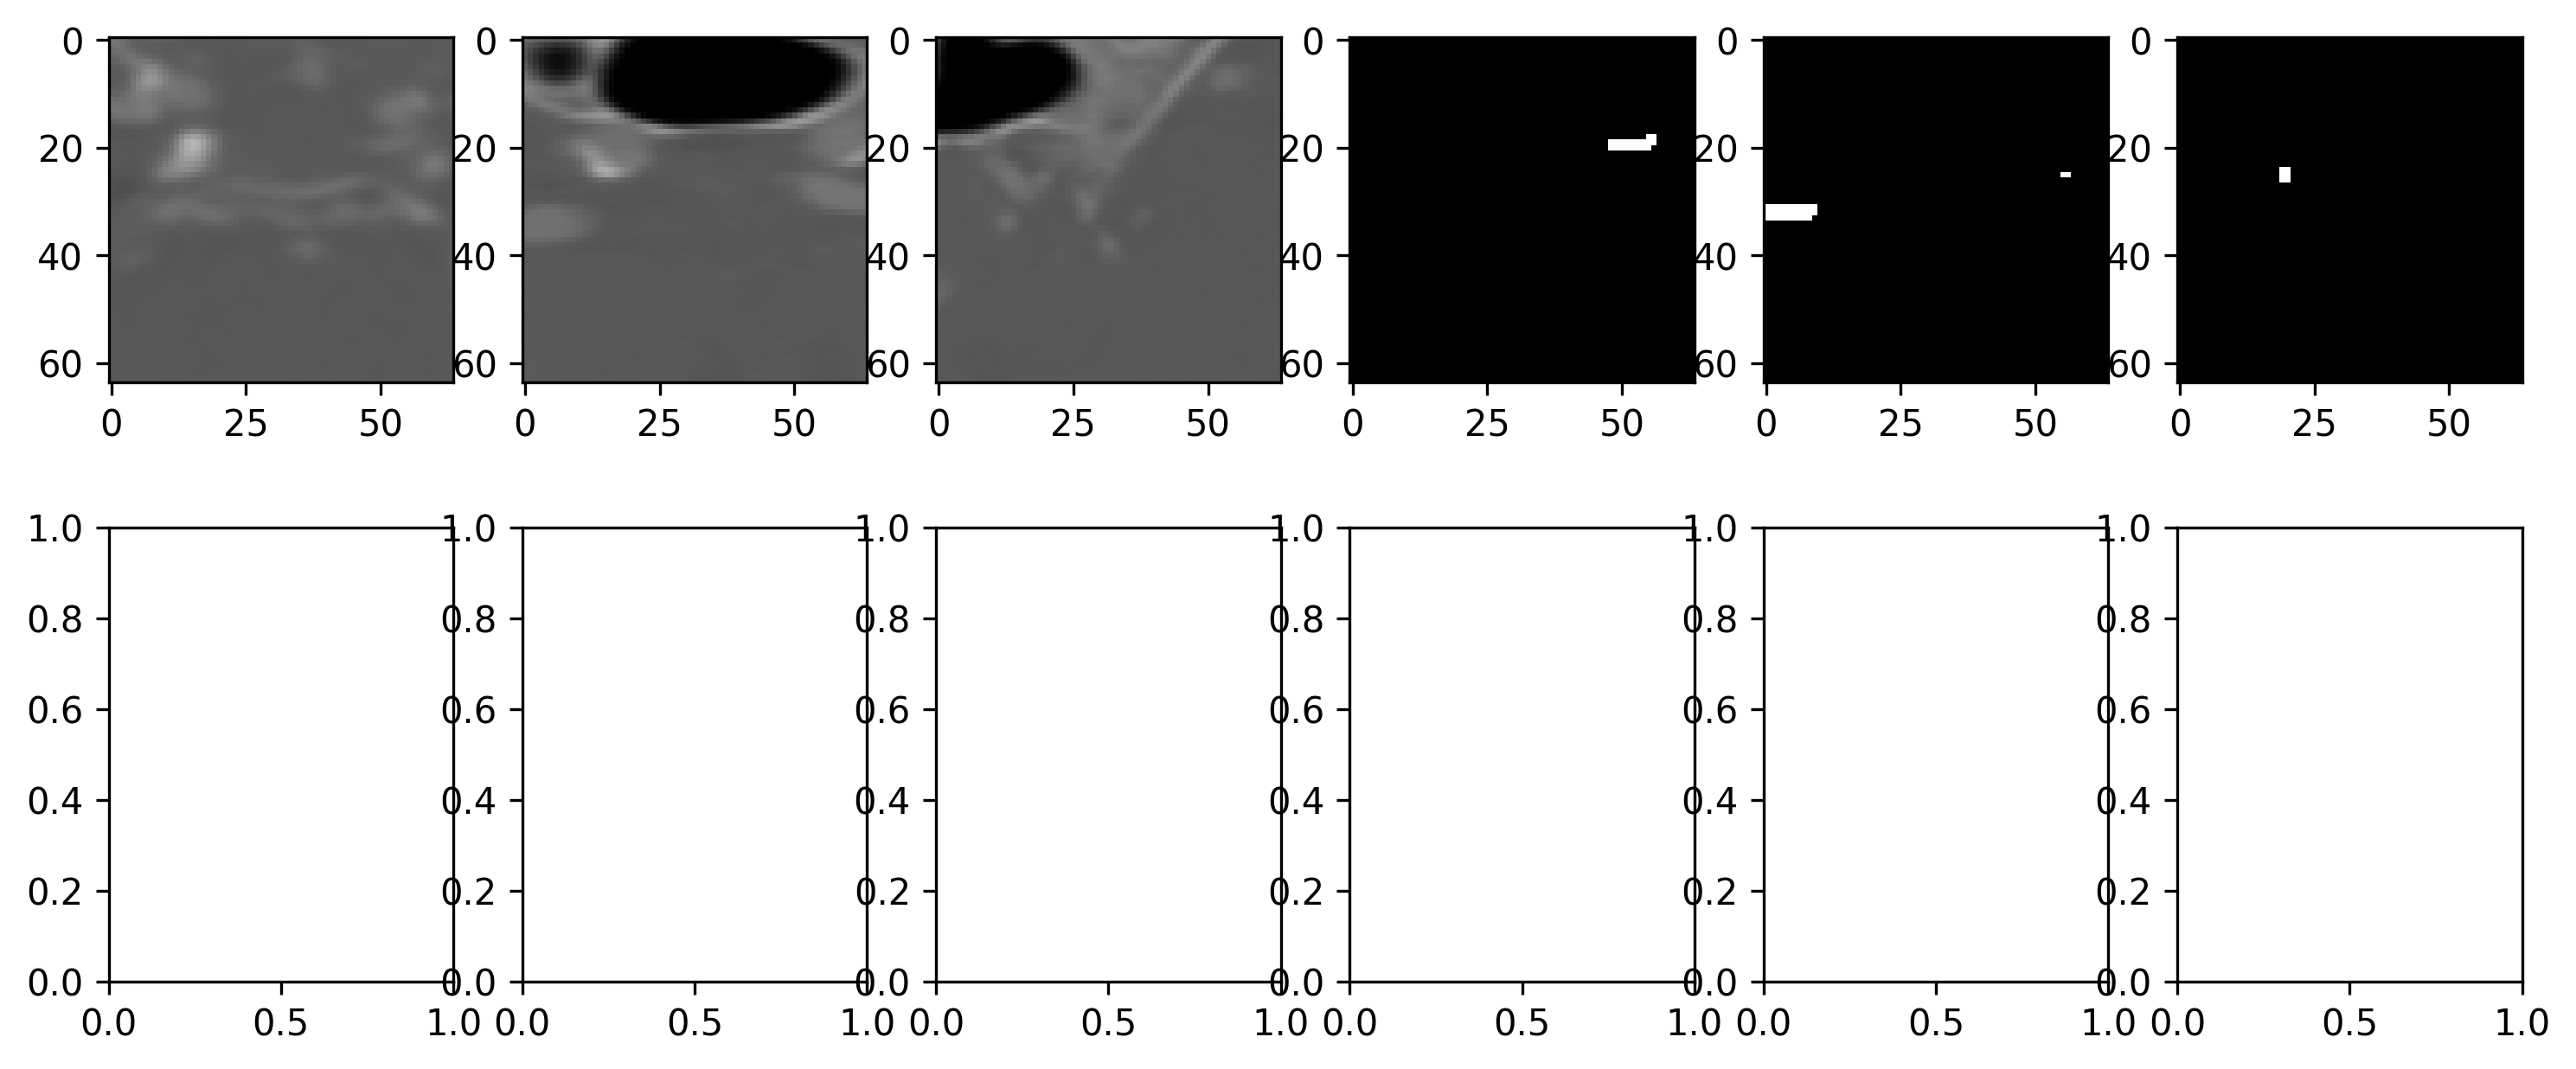

In [136]:
image = sample["image"][0]
label = sample["label"][0]
ctr = sample["ctr"].astype(int)[0]
fig, axs = plt.subplots(2,6, dpi= 300, figsize=(12,5))

axs[0,0].imshow(image[ ctr[0],:,:], cmap="gray", vmin=-1000, vmax=2000)
axs[0,1].imshow(image[:,ctr[1],:], cmap="gray", vmin=-1000, vmax=2000)
axs[0,2].imshow(image[:,:,ctr[2]], cmap="gray", vmin=-1000, vmax=2000)

axs[0,3].imshow(label[ ctr[0],:,:], cmap="gray")
axs[0,4].imshow(label[:,ctr[1],:], cmap="gray")
axs[0,5].imshow(label[:,:,ctr[2]], cmap="gray")

print(rad_t, rad)
print(ctr_t, ctr)